In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
vocab_size=10000
max_length=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)
x_train=pad_sequences(x_train,maxlen=max_length)
x_test=pad_sequences(x_test,maxlen=max_length)
print(x_train.shape,x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000, 200) (25000, 200)


In [ ]:
model=Sequential([
    Embedding(vocab_size,64,input_length=max_length),
    SimpleRNN(64),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6355 - loss: 0.6230 - val_accuracy: 0.7986 - val_loss: 0.4447
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8587 - loss: 0.3377 - val_accuracy: 0.8404 - val_loss: 0.3853
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9282 - loss: 0.1908 - val_accuracy: 0.8030 - val_loss: 0.4639
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9725 - loss: 0.0846 - val_accuracy: 0.8224 - val_loss: 0.5041
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9865 - loss: 0.0457 - val_accuracy: 0.8196 - val_loss: 0.5791


In [ ]:
loss,acc=model.evaluate(x_test,y_test)
print("Test Accuracy:",acc)
pred=(model.predict(x_test)>0.5).astype(int)
print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1:",f1_score(y_test,pred))
print("Confusion Matrix\n",confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8121 - loss: 0.6069
Test Accuracy: 0.8120800256729126
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Accuracy: 0.81208
Precision: 0.8354256233877903
Recall: 0.77728
F1: 0.8053046000828844
Confusion Matrix
 [[10586  1914]
 [ 2784  9716]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82     12500
           1       0.84      0.78      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



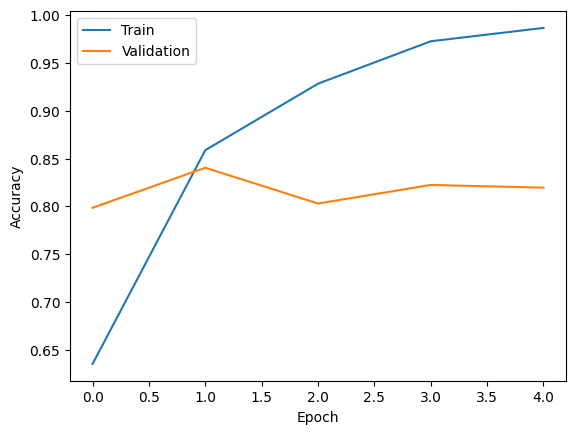

In [ ]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
